<a href="https://colab.research.google.com/github/BlackSwan96/index.html/blob/main/My05CodeProportions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inferential Statistics and Tests for Proportions

numYes, numNo = 102500000.0, 147500000.0
pvbar, pvsd1 = 0.4101, 0.0123


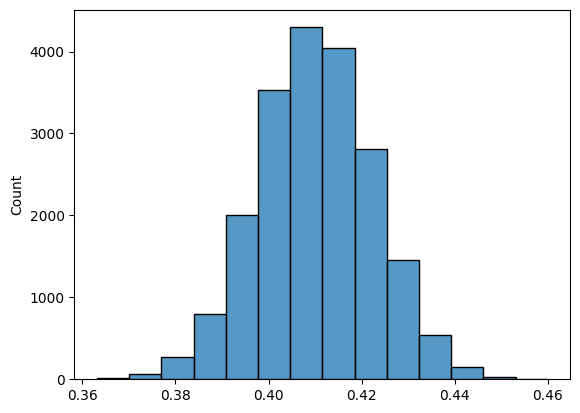

In [ ]:
# Simulation of Sample Proportions
import numpy as np; import seaborn as sns
from sklearn.utils import resample
p = 0.41   # true population proportion
N = 250000000; # population size
n = 1600; # sample size
numsamples = 20000 # number of samples in the simulation
numYes = p*N;
numNo = (1-p)*N;
print('numYes, numNo = {:.1f}, {:.1f}'.format(numYes, numNo))
possible_entries = np.concatenate((np.repeat(1,numYes), np.repeat(0,numNo)))
pv = np.repeat(0.0,numsamples)  # sample proportions
for j in range(numsamples):
  # resample below produces a SIMPLE RANDOM SAMPLE!!!
  onesample = resample(possible_entries, n_samples=n, replace=True)
  pv[j] = np.sum( onesample == 1) / n

sns.histplot(pv,bins=14)   # create histogram of sample proportions
pvbar = np.mean(pv); # mean of sample proportions
pvsd1  = np.std(pv,ddof=1);  # standard deviation of sample proportions
print('pvbar, pvsd1 = {:.4f}, {:.4f}'.format(pvbar, pvsd1))

numYes, numNo = 102500000.0, 147500000.0
pvbar, pvsd1 = 0.4101, 0.0247


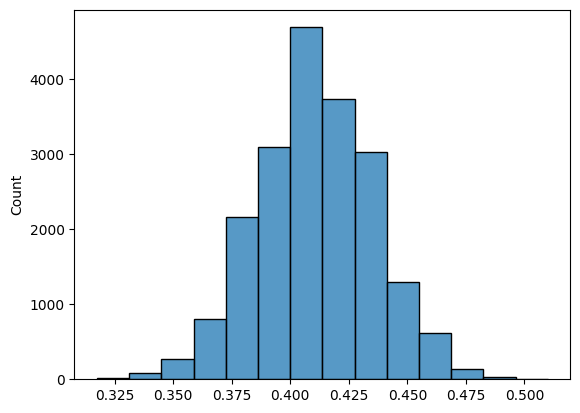

In [ ]:
# Simulation of Sample Proportions
import numpy as np; import seaborn as sns
from sklearn.utils import resample
p = 0.41   # true population proportion
N = 250000000; # population size
n = 400; # sample size
numsamples = 20000 # number of samples in the simulation
numYes = p*N;
numNo = (1-p)*N;
print('numYes, numNo = {:.1f}, {:.1f}'.format(numYes, numNo))
possible_entries = np.concatenate((np.repeat(1,numYes), np.repeat(0,numNo)))
pv = np.repeat(0.0,numsamples)  # sample proportions
for j in range(numsamples):
  # resample below produces a SIMPLE RANDOM SAMPLE!!!
  onesample = resample(possible_entries, n_samples=n, replace=True)
  pv[j] = np.sum( onesample == 1) / n

sns.histplot(pv,bins=14)   # create histogram of sample proportions
pvbar = np.mean(pv); # mean of sample proportions
pvsd1  = np.std(pv,ddof=1);  # standard deviation of sample proportions
print('pvbar, pvsd1 = {:.4f}, {:.4f}'.format(pvbar, pvsd1))

numYes, numNo = 25000000.0, 225000000.0
pvbar, pvsd1 = 0.0999, 0.0598


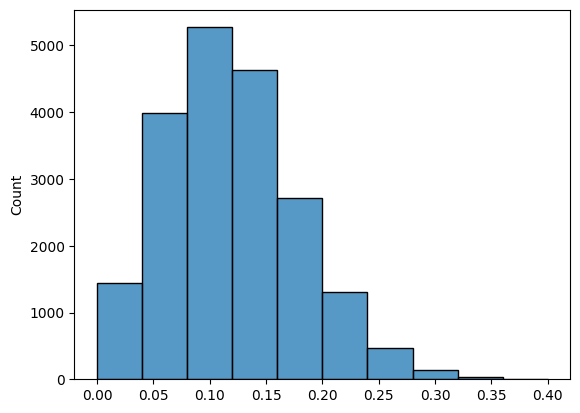

In [ ]:
# Simulation of Sample Proportions
import numpy as np; import seaborn as sns
from sklearn.utils import resample
p = 0.10   # true population proportion
N = 250000000; # population size
n = 25; # sample size
numsamples = 20000 # number of samples in the simulation
numYes = p*N;
numNo = (1-p)*N;
print('numYes, numNo = {:.1f}, {:.1f}'.format(numYes, numNo))
possible_entries = np.concatenate((np.repeat(1,numYes), np.repeat(0,numNo)))
pv = np.repeat(0.0,numsamples)  # sample proportions
for j in range(numsamples):
  # resample below produces a SIMPLE RANDOM SAMPLE!!!
  onesample = resample(possible_entries, n_samples=n, replace=True)
  pv[j] = np.sum( onesample == 1) / n

sns.histplot(pv,bins=10)   # create histogram of sample proportions
pvbar = np.mean(pv); # mean of sample proportions
pvsd1  = np.std(pv,ddof=1);  # standard deviation of sample proportions
print('pvbar, pvsd1 = {:.4f}, {:.4f}'.format(pvbar, pvsd1))

Text(3.2, 0.03, '0.025')

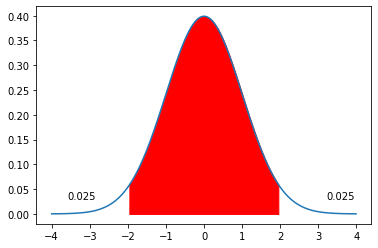

In [ ]:
import numpy as np;  import matplotlib.pyplot as plt
from scipy.stats import norm
xv = np.arange(-4, 4, 0.01)
plt.plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-1.96,1.96,0.01)
plt.fill_between(px,norm.pdf(px,0,1),color='r')
plt.text(-3.6,0.03,"0.025"); plt.text(3.2,0.03,"0.025")

Proportion inside =  0.97


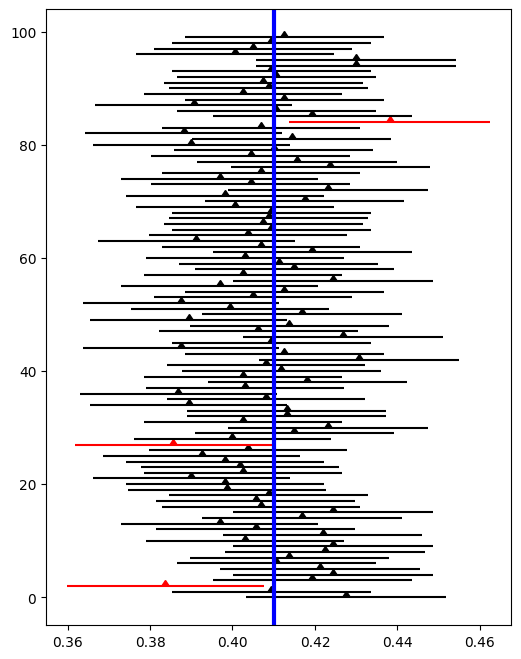

In [ ]:
# Simulation of Sample Proportions
import numpy as np; import seaborn as sns
from sklearn.utils import resample; import matplotlib.pyplot as plt
p0 = 0.41   # true population proportion
N = 250000000; # population size
n = 1600; # sample size
numsamples = 100 # number of samples in the simulation
numYes = p0*N;
numNo = (1-p0)*N;
numin = 0;  #  number of p's inside
# print('numYes, numNo = ', numYes, numNo)
possible_entries = np.concatenate((np.repeat(1,numYes), np.repeat(0,numNo)))
CIL = np.repeat(0.0,numsamples);  CIR = np.repeat(0.0,numsamples);
_, ax = plt.subplots(1, 1, figsize=(6, 8))
for j in range(numsamples):
  # resample below produces a SIMPLE RANDOM SAMPLE!!!
  onesample = resample(possible_entries, n_samples=n, replace=True)
  phat = np.sum( onesample == 1) / n
  SE = np.sqrt(phat*(1-phat)/n)
  CIL[j] = phat - 1.96*SE
  CIR[j] = phat + 1.96*SE
  if (p0 > CIL[j] and p0 < CIR[j]):
        # interval contains p
        numin = numin + 1
        ax.errorbar(phat, j, lolims=True, xerr=1.96*SE, \
                    yerr=0.0, linestyle='', c='black')
  else:
        # interval does not contain p
        ax.errorbar(phat, j, lolims=True, xerr=1.96*SE, \
                    yerr=0.0, linestyle='', c='red')

ax.axvline(p0, color='blue',lw=3)
print('Proportion inside = ', numin/numsamples)

__Example__

A sample of $n=1600$ randomly chosen voters is taken and $x=675$ of them approve presidential performance.  Construct and interpret a 95% conﬁdence interval for the population proportion.  

In [ ]:
import numpy as np; from scipy.stats import norm; import pandas as pd
alpha = 0.05 # error level corresponding to 95% confidence level
x = 675; # number of Yes
n = 1600; # sample size
phat = x/n  # sample proportion
print('success/failure condtions  n*phat, n*(1-phat) <=10?? ', n*phat, n*(1-phat))
SE = np.sqrt(phat*(1-phat)/n);   # standard error
zstar = norm.ppf(1-alpha/2);     # z critical
MarginErr = zstar*SE;  # margin of error
CIL = phat - MarginErr;   CIR = phat + MarginErr;
df = pd.DataFrame({'phat':phat,'SE':SE,'zstar':zstar,   \
                  'MarginErr':MarginErr,'CIL':CIL,'CIR':CIR},index=[0]);
pd.set_option("display.precision", 4); print(df,'\n')

success/failure condtions  n*phat, n*(1-phat) <=10??  675.0 925.0
     phat      SE  zstar  MarginErr     CIL     CIR
0  0.4219  0.0123   1.96     0.0242  0.3977  0.4461 



### General confidence intervals

The most common level of confidence is 95%,  but any level of confidence $1-\alpha$ equivalent to $\alpha$ level of error can be used.  The Figure below shows confidence level areas for 90%, 95%, and 99% on the standard normal curve.

,ConfLevel,alpha,zstar
0,0.90,0.10,1.644854
1,0.95,0.05,1.959964
2,0.99,0.01,2.575829


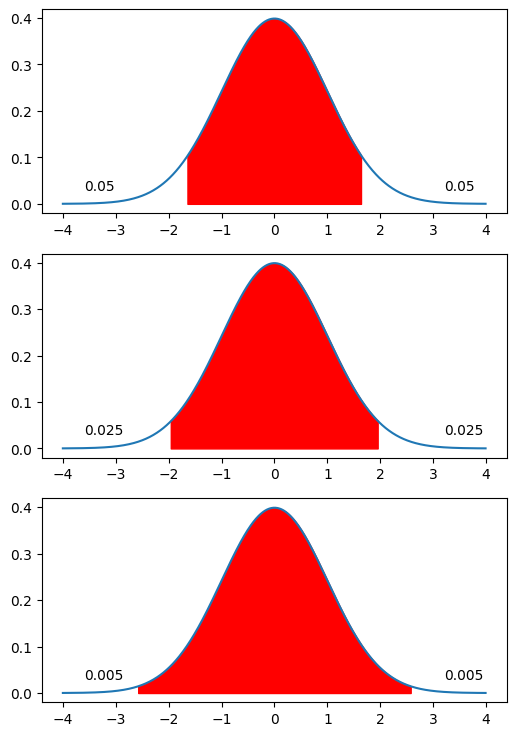

In [ ]:
import numpy as np;  import matplotlib.pyplot as plt
from scipy.stats import norm;  import pandas as pd
fig, axs = plt.subplots(3, 1, figsize=(6, 9), sharey=True)
xv = np.arange(-4, 4, 0.01)
ConfLevel = np.array([0.9,0.95,0.99])
alpha = 1-ConfLevel
zstar = norm.ppf(1-alpha/2);
df = pd.DataFrame({'ConfLevel':ConfLevel,'alpha':alpha,'zstar':zstar});

axs[0].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[0],zstar[0],0.01)
axs[0].fill_between(px,norm.pdf(px,0,1),color='r')
axs[0].text(-3.6,0.03,"0.05"); axs[0].text(3.2,0.03,"0.05")

axs[1].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[1],zstar[1],0.01)
axs[1].fill_between(px,norm.pdf(px,0,1),color='r')
axs[1].text(-3.6,0.03,"0.025"); axs[1].text(3.2,0.03,"0.025")

axs[2].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[2],zstar[2],0.01)
axs[2].fill_between(px,norm.pdf(px,0,1),color='r')
axs[2].text(-3.6,0.03,"0.005"); axs[2].text(3.2,0.03,"0.005")
df

In [ ]:
import numpy as np; from scipy.stats import norm; import pandas as pd
ConfLevel = np.array([0.9,0.95,0.99])  # confidence level
alpha = 1-ConfLevel  # error level corresponding to confidence level
x = 675; # number of Yes
n = 1600; # sample size
phat = x/n  # sample proportion
print('sample proportion phat = ', x ,'/',n,'=',phat)
print('success/failure condtions  n*phat, n*(1-phat) <=10?? ', n*phat, n*(1-phat))
SE = np.sqrt(phat*(1-phat)/n);   # standard error
print('Standard error = sqrt(phat*(1-phat)/n) = ',SE)
zstar = norm.ppf(1-alpha/2);     # z critical
MarginErr = zstar*SE;  # margin of error
CIL = phat - MarginErr;   CIR = phat + MarginErr;
df = pd.DataFrame({'ConfLevel':ConfLevel,'alpha':alpha,'zstar':zstar,'SE':SE,   \
                   'e':MarginErr,'phat':phat,'CIL':CIL,'CIR':CIR});
pd.set_option("display.precision", 4); df

sample proportion phat =  675 / 1600 = 0.421875
success/failure condtions  n*phat, n*(1-phat) <=10??  675.0 925.0
Standard error = sqrt(phat*(1-phat)/n) =  0.012346469241624303


,ConfLevel,alpha,zstar,SE,e,phat,CIL,CIR
0,0.90,0.10,1.6449,0.0123,0.0203,0.4219,0.4016,0.4422
1,0.95,0.05,1.9600,0.0123,0.0242,0.4219,0.3977,0.4461
2,0.99,0.01,2.5758,0.0123,0.0318,0.4219,0.3901,0.4537


### More examples of Proportion Confidence Intervals

__Example__
      
A company claims that only about 8% of its widgets can be defective. A sample of $n=100$ of randomly chosen widgets is taken and $x=10$ of them turn out to be defective.  Construct 90%, 95%, and 99% confidence intervals and interpret the results.  

It is much more efficient to write a Python generic function to compute all confidence intervals in one shot.

In [ ]:
def OneProportionCI(x,n,ConfidenceLevels):
  import numpy as np; from scipy.stats import norm; import pandas as pd
  import matplotlib.pyplot as plt
  print('One Proportion Confidence Interval function')
  print('Number of successes x = ', x)
  print('Sample size n = ', n)
  print('Confidence Levels',ConfidenceLevels)

  phat = x/n; phat  # sample proportion
  print('sample proportion phat = {:.2f}/{:d} = {:.4f}'.format(x,n,phat))

  ConfLevel = np.array(ConfidenceLevels)  # confidence level
  alpha = 1-ConfLevel  # error level corresponding to confidence level
  print('success/failure: n*phat = {:.3f}, n*(1-phat) = {:.3f}  <=10?? '
         .format(n*phat, n*(1-phat)))
  SEci = np.sqrt(phat*(1-phat)/n);   # standard error for Confidence Interval (CI)
  print('Standard Error = SEci =sqrt(phat*(1-phat)/n) =')
  print('       sqrt({:.4f}*(1-{:.4f})/{:d}) = {:.4f}'.format(phat,phat,n,SEci))
  zstar = norm.ppf(1-alpha/2);     # z critical
  MarginErr = zstar*SEci;  # margin of error
  CIL = phat - MarginErr;   CIR = phat + MarginErr;
  df = pd.DataFrame({'ConfLevel':ConfLevel,'zstar':zstar,'SEci':SEci,   \
                    'MarginErr':MarginErr,'phat':phat,'CIL':CIL,'CIR':CIR});
  pd.set_option("display.precision", 4); print(df,'\n')


OneProportionCI(x=10,n=100,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Confidence Interval function
Number of successes x =  10
Sample size n =  100
Confidence Levels [0.9, 0.95, 0.99]
sample proportion phat = 10.00/100 = 0.1000
success/failure: n*phat = 10.000, n*(1-phat) = 90.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.1000*(1-0.1000)/100) = 0.0300
   ConfLevel   zstar  SEci  MarginErr  phat     CIL     CIR
0       0.90  1.6449  0.03     0.0493   0.1  0.0507  0.1493
1       0.95  1.9600  0.03     0.0588   0.1  0.0412  0.1588
2       0.99  2.5758  0.03     0.0773   0.1  0.0227  0.1773 



In [ ]:
OneProportionCI(x=0.86*159,n=159,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Confidence Interval function
Number of successes x =  136.74
Sample size n =  159
Confidence Levels [0.9, 0.95, 0.99]
sample proportion phat = 136.74/159 = 0.8600
success/failure: n*phat = 136.740, n*(1-phat) = 22.260  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.8600*(1-0.8600)/159) = 0.0275
   ConfLevel   zstar    SEci  MarginErr  phat     CIL     CIR
0       0.90  1.6449  0.0275     0.0453  0.86  0.8147  0.9053
1       0.95  1.9600  0.0275     0.0539  0.86  0.8061  0.9139
2       0.99  2.5758  0.0275     0.0709  0.86  0.7891  0.9309 



In [ ]:
OneProportionCI(x=310*0.26,n=310,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Confidence Interval function
Number of successes x =  80.60000000000001
Sample size n =  310
Confidence Levels [0.9, 0.95, 0.99]
sample proportion phat = 80.60/310 = 0.2600
success/failure: n*phat = 80.600, n*(1-phat) = 229.400  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.2600*(1-0.2600)/310) = 0.0249
   ConfLevel   zstar    SEci  MarginErr  phat     CIL     CIR
0       0.90  1.6449  0.0249     0.0410  0.26  0.2190  0.3010
1       0.95  1.9600  0.0249     0.0488  0.26  0.2112  0.3088
2       0.99  2.5758  0.0249     0.0642  0.26  0.1958  0.3242 



In [ ]:
def OneProportionTest(x,n,p0,ConfidenceLevels):
  import numpy as np; from scipy.stats import norm; import pandas as pd
  import matplotlib.pyplot as plt
  print('One Proportion Test function')
  print('Number of successes x = ', x)
  print('Sample size n = ', n)
  print('Null hypothesis claimed proportion p0 = ', p0)
  print('Confidence Levels',ConfidenceLevels,'\n')

  print('H0: p = p0')
  print('H1: p not p0  or one sided test\n')

  phat = x/n; phat  # sample proportion
  print('sample proportion phat = {:.2f}/{:d} = {:.4f}'.format(x,n,phat))

  print('Hypothesis Testing Approach:')
  print('success/failure: n*p0 = {:.4f}, n*(1-p0) = {:.4f}  <=10?? '
         .format(n*p0, n*(1-p0)))
  SE = np.sqrt(p0*(1-p0)/n);  # standard error
  print('Standard Error = SE =sqrt(p0*(1-p0)/n) =')
  print('   sqrt({:.4f}*(1-{:.4f})/{:d}) = {:.4f}'.format(p0,p0,n,SE))
  z = (phat-p0)/SE;    # standardized statistic
  print('Standardized z = (phat-p0)/SE = ({:.4f}-{:.4f})/{:.4f}={:.4f}'
          .format(phat,p0,SE,z))
  pval2 = 2*(1-norm.cdf(np.abs(z)));   #  2 sided p-value
  print('P-values: 2-sided and 1 sided:  ', pval2,pval2/2)

  # P-value graphical illustration FYI-----------------------------
  fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=False)
  xv = np.arange(p0-4*SE, p0+4*SE, 0.001);  diff = np.abs(p0-phat)
  axs[0].plot(xv, norm.pdf(xv, p0, SE))
  xL=np.arange(p0-4*SE,p0-diff,0.001)
  axs[0].fill_between(xL,norm.pdf(xL,p0,SE),color='r')
  xR=np.arange(p0+diff,p0+4*SE,0.001)
  axs[0].fill_between(xR,norm.pdf(xR,p0,SE),color='b')
  xv = np.arange(-4, 4, 0.001)
  axs[1].plot(xv, norm.pdf(xv, 0, 1))
  xL=np.arange(-4,-np.abs(z),0.001)
  axs[1].fill_between(xL,norm.pdf(xL,0,1),color='r')
  xR=np.arange(np.abs(z),4,0.001)
  axs[1].fill_between(xR,norm.pdf(xR,0,1),color='b')
  #------------------------------------------------------------------

  ConfLevel = np.array(ConfidenceLevels)  # confidence level
  alpha = 1-ConfLevel  # error level corresponding to confidence level
  print('\nConfidence Interval Approach: \n')
  print('success/failure: n*phat = {:.3f}, n*(1-phat) = {:.3f}  <=10?? '
         .format(n*phat, n*(1-phat)))
  SEci = np.sqrt(phat*(1-phat)/n);   # standard error (CI)
  print('Standard Error = SEci =sqrt(phat*(1-phat)/n) =')
  print('   sqrt({:.4f}*(1-{:.4f})/{:d} = {:.4f} )'.format(phat,phat,n,SEci))
  zstar = norm.ppf(1-alpha/2);     # z critical
  MarginErr = zstar*SEci;  # margin of error
  CIL = phat - MarginErr;   CIR = phat + MarginErr;
  df = pd.DataFrame({'ConfLevel':ConfLevel,'zstar':zstar,'SEci':SEci,   \
                    'MarginErr':MarginErr,'phat':phat,'CIL':CIL,'CIR':CIR});
  pd.set_option("display.precision", 4); print(df,'\n')



One Proportion Test function
Number of successes x =  550
Sample size n =  1200
Null hypothesis claimed proportion p0 =  0.5
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 550.00/1200 = 0.4583
Hypothesis Testing Approach:
success/failure: n*p0 = 600.0000, n*(1-p0) = 600.0000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.5000*(1-0.5000)/1200) = 0.0144
Standardized z = (phat-p0)/SE = (0.4583-0.5000)/0.0144=-2.8868
P-values: 2-sided and 1 sided:   0.0038924171227785465 0.0019462085613892732

Confidence Interval Approach: 

success/failure: n*phat = 550.000, n*(1-phat) = 650.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.4583*(1-0.4583)/1200 = 0.0144 )
   ConfLevel   zstar    SEci  MarginErr    phat     CIL     CIR
0       0.90  1.6449  0.0144     0.0237  0.4583  0.4347  0.4820
1       0.95  1.9600  0.0144     0.0282  0.4583  0.4301  0.4865
2       0.99  2.5758  0.0144     0.0370  0.45

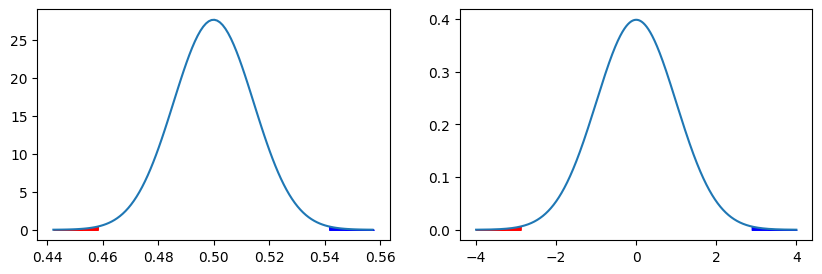

In [ ]:
OneProportionTest(x=550,n=1200,p0=0.5,ConfidenceLevels=[0.9,0.95,0.99])

### More Proportion Hypothesis Tests Examples

__Example__

A Company claims that only about 9% of its widgets are defective.  A random sample of 120 widgets is taken and 14 of them turn out to be defective. Test the company's claim at a 5% level.


$\textbf{H0}: p= 0.09$ (company's claim - __assume true__).  
$\textbf{H1}: p \ne 0.09$ (not what they claim).   

One Proportion Test function
Number of successes x =  14
Sample size n =  120
Null hypothesis claimed proportion p0 =  0.09
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 14.00/120 = 0.1167
Hypothesis Testing Approach:
success/failure: n*p0 = 10.8000, n*(1-p0) = 109.2000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.0900*(1-0.0900)/120) = 0.0261
Standardized z = (phat-p0)/SE = (0.1167-0.0900)/0.0261=1.0207
P-values: 2-sided and 1 sided:   0.30737510892876196 0.15368755446438098

Confidence Interval Approach: 

success/failure: n*phat = 14.000, n*(1-phat) = 106.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.1167*(1-0.1167)/120 = 0.0293 )
   ConfLevel   zstar    SEci  MarginErr    phat     CIL     CIR
0       0.90  1.6449  0.0293     0.0482  0.1167  0.0685  0.1649
1       0.95  1.9600  0.0293     0.0574  0.1167  0.0592  0.1741
2       0.99  2.5758  0.0293     0.0755  0.1167  0.0412  

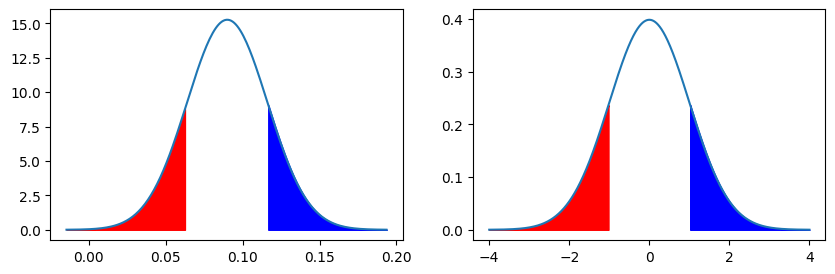

In [ ]:
OneProportionTest(x=14,n=120,p0=0.09,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Test function
Number of successes x =  32
Sample size n =  300
Null hypothesis claimed proportion p0 =  0.07
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 32.00/300 = 0.1067
Hypothesis Testing Approach:
success/failure: n*p0 = 21.0000, n*(1-p0) = 279.0000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.0700*(1-0.0700)/300) = 0.0147
Standardized z = (phat-p0)/SE = (0.1067-0.0700)/0.0147=2.4891
P-values: 2-sided and 1 sided:   0.012806855145407026 0.006403427572703513

Confidence Interval Approach: 

success/failure: n*phat = 32.000, n*(1-phat) = 268.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.1067*(1-0.1067)/300 = 0.0178 )
   ConfLevel   zstar    SEci  MarginErr    phat     CIL     CIR
0       0.90  1.6449  0.0178     0.0293  0.1067  0.0774  0.1360
1       0.95  1.9600  0.0178     0.0349  0.1067  0.0717  0.1416
2       0.99  2.5758  0.0178     0.0459  0.1067  0.0608

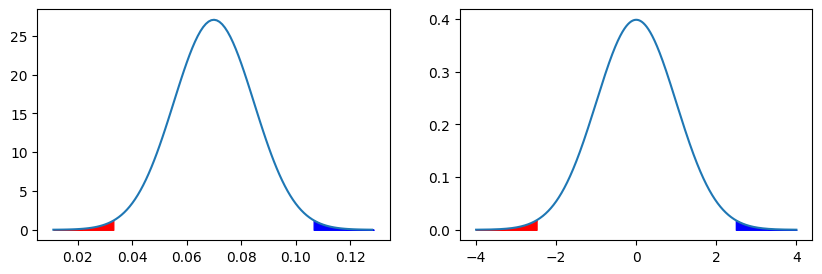

In [ ]:
OneProportionTest(x=32,n=300,p0=0.07,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Test function
Number of successes x =  149
Sample size n =  200
Null hypothesis claimed proportion p0 =  0.8
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 149.00/200 = 0.7450
Hypothesis Testing Approach:
success/failure: n*p0 = 160.0000, n*(1-p0) = 40.0000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.8000*(1-0.8000)/200) = 0.0283
Standardized z = (phat-p0)/SE = (0.7450-0.8000)/0.0283=-1.9445
P-values: 2-sided and 1 sided:   0.051829927217909466 0.025914963608954733

Confidence Interval Approach: 

success/failure: n*phat = 149.000, n*(1-phat) = 51.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.7450*(1-0.7450)/200 = 0.0308 )
   ConfLevel   zstar    SEci  MarginErr   phat     CIL     CIR
0       0.90  1.6449  0.0308     0.0507  0.745  0.6943  0.7957
1       0.95  1.9600  0.0308     0.0604  0.745  0.6846  0.8054
2       0.99  2.5758  0.0308     0.0794  0.745  0.6656  

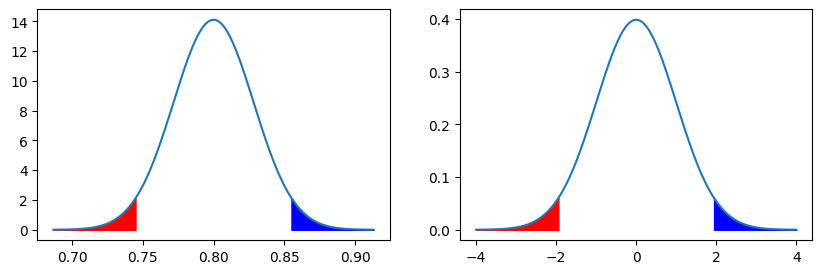

In [ ]:
OneProportionTest(x=149,n=200,p0=0.80,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Test function
Number of successes x =  155
Sample size n =  200
Null hypothesis claimed proportion p0 =  0.8
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 155.00/200 = 0.7750
Hypothesis Testing Approach:
success/failure: n*p0 = 160.0000, n*(1-p0) = 40.0000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.8000*(1-0.8000)/200) = 0.0283
Standardized z = (phat-p0)/SE = (0.7750-0.8000)/0.0283=-0.8839
P-values: 2-sided and 1 sided:   0.37675911781158167 0.18837955890579083

Confidence Interval Approach: 

success/failure: n*phat = 155.000, n*(1-phat) = 45.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.7750*(1-0.7750)/200 = 0.0295 )
   ConfLevel   zstar    SEci  MarginErr   phat     CIL     CIR
0       0.90  1.6449  0.0295     0.0486  0.775  0.7264  0.8236
1       0.95  1.9600  0.0295     0.0579  0.775  0.7171  0.8329
2       0.99  2.5758  0.0295     0.0761  0.775  0.6989  0.

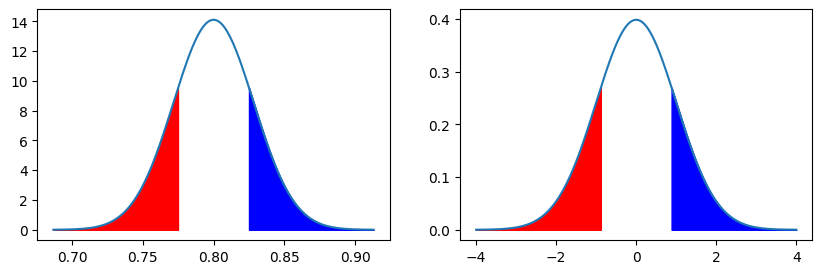

In [ ]:
OneProportionTest(x=155,n=200,p0=0.80,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Test function
Number of successes x =  629
Sample size n =  1000
Null hypothesis claimed proportion p0 =  0.6
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 629.00/1000 = 0.6290
Hypothesis Testing Approach:
success/failure: n*p0 = 600.0000, n*(1-p0) = 400.0000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.6000*(1-0.6000)/1000) = 0.0155
Standardized z = (phat-p0)/SE = (0.6290-0.6000)/0.0155=1.8719
P-values: 2-sided and 1 sided:   0.06121463495460189 0.030607317477300944

Confidence Interval Approach: 

success/failure: n*phat = 629.000, n*(1-phat) = 371.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.6290*(1-0.6290)/1000 = 0.0153 )
   ConfLevel   zstar    SEci  MarginErr   phat     CIL     CIR
0       0.90  1.6449  0.0153     0.0251  0.629  0.6039  0.6541
1       0.95  1.9600  0.0153     0.0299  0.629  0.5991  0.6589
2       0.99  2.5758  0.0153     0.0393  0.629  0.58

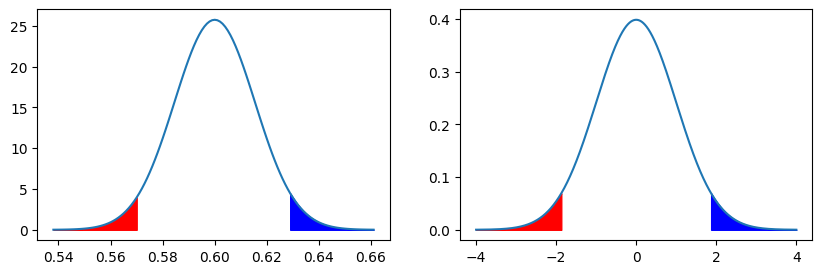

In [ ]:
OneProportionTest(x=629,n=1000,p0=0.60,ConfidenceLevels=[0.9,0.95,0.99])

One Proportion Test function
Number of successes x =  282
Sample size n =  649
Null hypothesis claimed proportion p0 =  0.46
Confidence Levels [0.8, 0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 282.00/649 = 0.4345
Hypothesis Testing Approach:
success/failure: n*p0 = 298.5400, n*(1-p0) = 350.4600  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.4600*(1-0.4600)/649) = 0.0196
Standardized z = (phat-p0)/SE = (0.4345-0.4600)/0.0196=-1.3027
P-values: 2-sided and 1 sided:   0.19268442667899932 0.09634221333949966

Confidence Interval Approach: 

success/failure: n*phat = 282.000, n*(1-phat) = 367.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.4345*(1-0.4345)/649 = 0.0195 )
   ConfLevel   zstar    SEci  MarginErr    phat     CIL     CIR
0       0.80  1.2816  0.0195     0.0249  0.4345  0.4096  0.4595
1       0.90  1.6449  0.0195     0.0320  0.4345  0.4025  0.4665
2       0.95  1.9600  0.0195     0.0381  0.4345

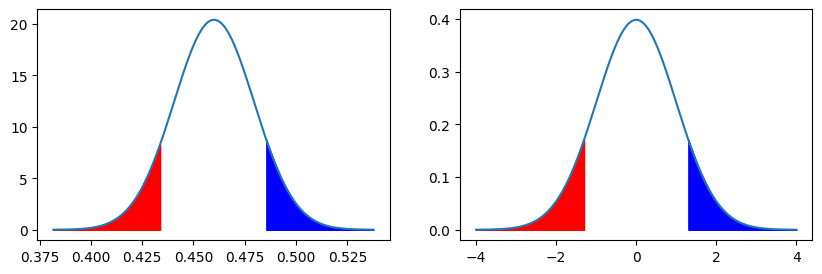

In [ ]:
OneProportionTest(x=282,n=649,p0=0.46,ConfidenceLevels=[0.8,0.9,0.95,0.99])

,ConfLevel,alpha,zstar
0,0.90,0.10,1.644854
1,0.95,0.05,1.959964
2,0.99,0.01,2.575829


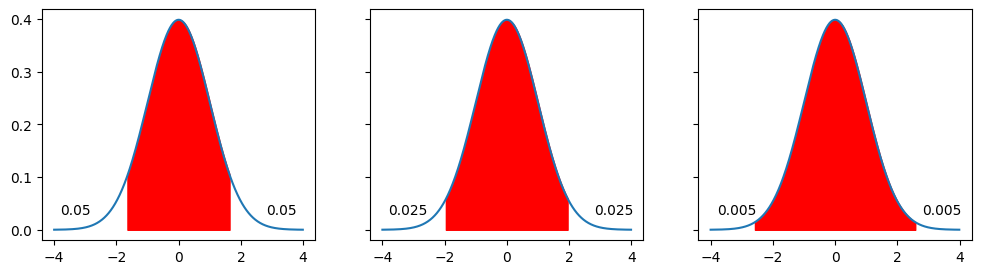

In [ ]:
import numpy as np;  import matplotlib.pyplot as plt
from scipy.stats import norm;  import pandas as pd
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
xv = np.arange(-4, 4, 0.01)
ConfLevel = np.array([0.9,0.95,0.99])
alpha = 1-ConfLevel
zstar = norm.ppf(1-alpha/2);
df = pd.DataFrame({'ConfLevel':ConfLevel,'alpha':alpha,'zstar':zstar});
axs[0].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[0],zstar[0],0.01)
axs[0].fill_between(px,norm.pdf(px,0,1),color='r')
axs[0].text(-3.8,0.03,"0.05"); axs[0].text(2.8,0.03,"0.05")

axs[1].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[1],zstar[1],0.01)
axs[1].fill_between(px,norm.pdf(px,0,1),color='r')
axs[1].text(-3.8,0.03,"0.025"); axs[1].text(2.8,0.03,"0.025")

axs[2].plot(xv, norm.pdf(xv, 0, 1))
px=np.arange(-zstar[2],zstar[2],0.01)
axs[2].fill_between(px,norm.pdf(px,0,1),color='r')
axs[2].text(-3.8,0.03,"0.005"); axs[2].text(2.8,0.03,"0.005")
df

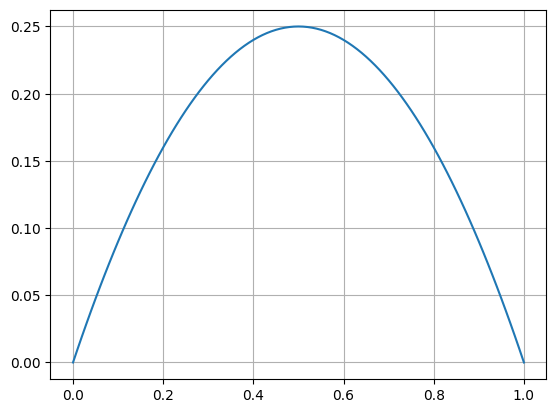

In [ ]:
import numpy as np;  import matplotlib.pyplot as plt
pv = np.arange(0,1.01,0.01)
fv = pv*(1-pv)
plt.plot(pv,fv);  plt.grid()

In [ ]:
from scipy.stats import norm
e = 0.01; alpha = 0.05;
zstar = norm.ppf(1-alpha/2);
print('e = {:.3f}, alpha = {:.3f}, zstar = {:.3f}'.format(e,alpha,zstar))
# (a)
p = 0.70
na = zstar**2*p*(1-p)/e**2;
print('For p = {:.3f} number needed for the study na = {:.3f}'.format(p,na))
# (b)
p = 0.50
nb = zstar**2*p*(1-p)/e**2;
print('For p = {:.3f} number needed for the study na = {:.3f}'.format(p,nb))

e = 0.010, alpha = 0.050, zstar = 1.960
For p = 0.700 number needed for the study na = 8067.064
For p = 0.500 number needed for the study na = 9603.647


In [ ]:
from scipy.stats import norm
e = 0.02; alpha = 0.05;
zstar = norm.ppf(1-alpha/2);
print('e = {:.3f}, alpha = {:.3f}, zstar = {:.3f}'.format(e,alpha,zstar))
# (a)
p = 0.70
na = zstar**2*p*(1-p)/e**2;
print('For p = {:.3f} number needed for the study na = {:.3f}'.format(p,na))
# (b)
p = 0.50
nb = zstar**2*p*(1-p)/e**2;
print('For p = {:.3f} number needed for the study na = {:.3f}'.format(p,nb))

e = 0.020, alpha = 0.050, zstar = 1.960
For p = 0.700 number needed for the study na = 2016.766
For p = 0.500 number needed for the study na = 2400.912


In [ ]:
from scipy.stats import norm;  import numpy as np;  import pandas as pd
e = 0.02;
ConfLevel = np.array([0.90,0.95,0.99]);  # confidence levels
alpha = 1-ConfLevel;     # corresponding error levels
zstar = norm.ppf(1-alpha/2);
print('e, alpha, zstar = ', e, alpha, zstar)
# (a)
p = 0.70
na = zstar**2*p*(1-p)/e**2;
df = pd.DataFrame({'ConfLevel':ConfLevel,'zstar':zstar,'na':na});
print('\nFor p = 0.7: \n',df)
# (b)
p = 0.50
nb = zstar**2*p*(1-p)/e**2;
df = pd.DataFrame({'ConfLevel':ConfLevel,'zstar':zstar,'nb':nb});
pd.set_option("display.precision", 4); print(df,'\n')

e, alpha, zstar =  0.02 [0.1  0.05 0.01] [1.64485363 1.95996398 2.5758293 ]

For p = 0.7: 
    ConfLevel   zstar         na
0       0.90  1.6449  1420.4103
1       0.95  1.9600  2016.7659
2       0.99  2.5758  3483.3207
   ConfLevel   zstar         nb
0       0.90  1.6449  1690.9647
1       0.95  1.9600  2400.9118
2       0.99  2.5758  4146.8104 



### One Proportion Tests for Data Files

In this section, one proportion test is applied to a data file, which requires first to determine each level counts as was done in Chapter 2.

__Example__

In this example, we are going to investigate the file HELPrct.csv used already in Chapter 2.  It contains a plethora of information about 453 substance abusers. We are concentrating on the proportion of homeless vs housed in this sample and want to test if it is 50/50.  

$\textbf{H0}: p= 0.5$ (__assume true__).  
$\textbf{H1}: p \ne 0.5$.   

homeless
housed      244
homeless    209
Name: count, dtype: int64


<Axes: xlabel='homeless'>

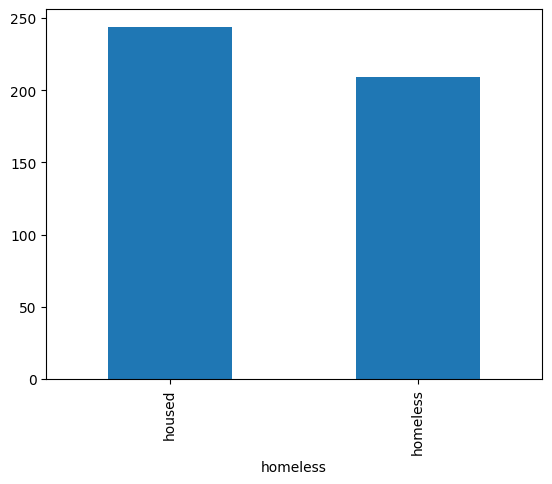

In [ ]:
import pandas as pd;   import numpy as np;  import seaborn as sns
url="https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv"
mydata = pd.read_csv(url)   # save as mydata file

mytable = mydata['homeless'].value_counts()  # value counts for each subgroup
  # .value_counts() is a method (object oriented programming) for this data type
print(mytable)
mytable.plot.bar()

One Proportion Test function
Number of successes x =  209
Sample size n =  453
Null hypothesis claimed proportion p0 =  0.5
Confidence Levels [0.9, 0.95, 0.99] 

H0: p = p0
H1: p not p0  or one sided test

sample proportion phat = 209.00/453 = 0.4614
Hypothesis Testing Approach:
success/failure: n*p0 = 226.5000, n*(1-p0) = 226.5000  <=10?? 
Standard Error = SE =sqrt(p0*(1-p0)/n) =
        sqrt(0.5000*(1-0.5000)/453) = 0.0235
Standardized z = (phat-p0)/SE = (0.4614-0.5000)/0.0235=-1.6444
P-values: 2-sided and 1 sided:   0.10008463625585429 0.05004231812792714

Confidence Interval Approach: 

success/failure: n*phat = 209.000, n*(1-phat) = 244.000  <=10?? 
Standard Error = SEci =sqrt(phat*(1-phat)/n) =
       sqrt(0.4614*(1-0.4614)/453 = 0.0234 )
   ConfLevel   zstar    SEci  MarginErr    phat     CIL     CIR
0       0.90  1.6449  0.0234     0.0385  0.4614  0.4228  0.4999
1       0.95  1.9600  0.0234     0.0459  0.4614  0.4155  0.5073
2       0.99  2.5758  0.0234     0.0603  0.4614  0.40

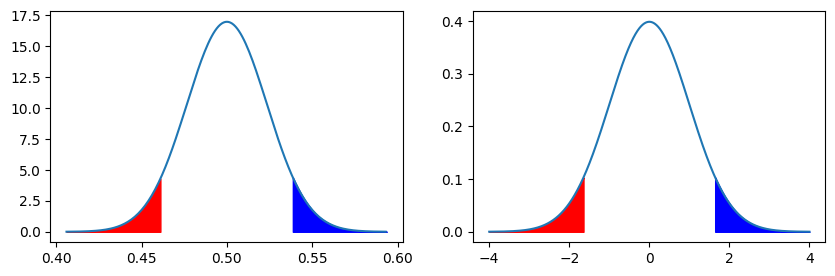

In [ ]:
OneProportionTest(x=209,n=209+244,p0=0.50,ConfidenceLevels=[0.9,0.95,0.99])

In [ ]:
def TwoProportionTest(x1,n1,x2,n2,CIs):
  import numpy as np; from scipy.stats import norm; import pandas as pd
  import matplotlib.pyplot as plt
  print('Two Proportions Test function')
  print('Group 1: number of yes x1 = {:d}, out of n1 = {:d}'.format(x1,n1))
  print('Group 2: number of yes x2 = {:d}, out of n2 = {:d}'.format(x2,n2))
  print('Confidence Levels',CIs,'\n')

  print('H0: p1-p2 = 0');
  print('H1: p1-p2 not 0  or one sided test\n')

  ph1 = x1/n1;   # sample proportion for 1st group
  ph2 = x2/n2;   # sample proportion for 2nd group
  print('sample proportions ph1 = {:d}/{:d} = {:.4f}'.format(x1,n1,ph1))
  print('sample proportions ph2 = {:d}/{:d} = {:.4f}'.format(x2,n2,ph2))
  print('Hypothesis Testing Approach:')
  pL = (x1+x2)/(n1+n2);
  print('p pooled = pL = ({:d}+{:d})/({:d}+{:d})={:.4f}'.format(x1,x2,n1,n2,pL))
  print("success-failure conditions n1*pL,n1*(1-pL),n2*pL, n2*(1-pL) >=10??")
  print('  {:.4f},{:.4f},{:.4f},{:.4f}'.format(n1*pL,n1*(1-pL),n2*pL,n2*(1-pL)))
  SE = np.sqrt(pL*(1-pL)*(1/n1+1/n2)); SE  # standard error
  print('Standard Error = SE =sqrt(pL*(1-pL)*(1/n1+1/n2)) =')
  print(' = sqrt({:.4f}(1-{:.4f})(1/{:d}+1/{:d})) = {:.4f}'.format(pL,pL,n1,n2,SE))
  diffphats = ph1-ph2;
  print('difference phat1-phat2 = {:.4f}-{:.4f} = {:.4f}'.
        format(ph1,ph2,diffphats))
  z = (diffphats)/SE;       # standardized statistic
  print('Standardized statistic = z = diffphats/SE = {:.4f}/{:.4f} = {:.4f}'
          .format(diffphats,SE,z))
  pval2 = 2*(1-norm.cdf(np.abs(z)));   #  2 sided p-value
  print('P-values: 2-sided and 1-sided: ',pval2,pval2/2)

  # P-value graphical illustration FYI-----------------------------
  fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharey=False)
  xv = np.arange(-4*SE, 4*SE, 0.001);  diff = np.abs(diffphats)
  axs[0].plot(xv, norm.pdf(xv, 0, SE))
  xL=np.arange(-4*SE,-diff,0.001)
  axs[0].fill_between(xL,norm.pdf(xL,0,SE),color='r')
  xR=np.arange(diff,4*SE,0.001)
  axs[0].fill_between(xR,norm.pdf(xR,0,SE),color='b')
  xv = np.arange(-4, 4, 0.001)
  axs[1].plot(xv, norm.pdf(xv, 0, 1))
  xL=np.arange(-4,-np.abs(z),0.001)
  axs[1].fill_between(xL,norm.pdf(xL,0,1),color='r')
  xR=np.arange(np.abs(z),4,0.001)
  axs[1].fill_between(xR,norm.pdf(xR,0,1),color='b')
  #------------------------------------------------------------------

  print('Confidence Interval Approach:')
  ConfLevel = np.array(CIs)  # confidence level
  alpha = 1-ConfLevel  # error level corresponding to confidence level
  print("success-failure conditions n1*ph1,n1*(1-ph1),n2*ph2, n2*(1-ph2) >=10??")
  print('  {:.4f},{:.4f},{:.4f},{:.4f}'.format(n1*ph1,n1*(1-ph1),n2*ph2,n2*(1-ph2)))
  SEci = np.sqrt(ph1*(1-ph1)/n1+ph2*(1-ph2)/n2);
  print('Standard Error = SEci =sqrt(ph1*(1-ph1)/n1+ph1*(1-ph2)/n2)) =')
  print(' = sqrt({:.4f}(1-{:.4f})/{:d}+{:.4f}(1-{:.4f})/{:d}) = {:.4f}'
        .format(ph1,ph1,n1,ph2,ph2,n2,SEci))
  zstar = norm.ppf(1-alpha/2);     # z critical
  MarginErr = zstar*SEci;  # margin of error
  CIL = diffphats - MarginErr;   CIR = diffphats + MarginErr;
  df = pd.DataFrame({'ConfLevel':ConfLevel,'zstar':zstar,'SEci':SEci,   \
                    'MarginErr':MarginErr,'diffphats':diffphats,'CIL':CIL,'CIR':CIR});
  pd.set_option("display.precision", 4); print(df,'\n')

Let's call on the function above to solve the given problem.

Two Proportions Test function
Group 1: number of yes x1 = 23, out of n1 = 80
Group 2: number of yes x2 = 30, out of n2 = 64
Confidence Levels [0.9, 0.95, 0.99] 

H0: p1-p2 = 0
H1: p1-p2 not 0  or one sided test

sample proportions ph1 = 23/80 = 0.2875
sample proportions ph2 = 30/64 = 0.4688
Hypothesis Testing Approach:
p pooled = pL = (23+30)/(80+64)=0.3681
success-failure conditions n1*pL,n1*(1-pL),n2*pL, n2*(1-pL) >=10??
  29.4444,50.5556,23.5556,40.4444
Standard Error = SE =sqrt(pL*(1-pL)*(1/n1+1/n2)) =
 = sqrt(0.3681(1-0.3681)(1/80+1/64)) = 0.0809
difference phat1-phat2 = 0.2875-0.4688 = -0.1813
Standardized statistic = z = diffphats/SE = -0.1813/0.0809 = -2.2410
P-values: 2-sided and 1-sided:  0.025028162676294263 0.012514081338147132
Confidence Interval Approach:
success-failure conditions n1*ph1,n1*(1-ph1),n2*ph2, n2*(1-ph2) >=10??
  23.0000,57.0000,30.0000,34.0000
Standard Error = SEci =sqrt(ph1*(1-ph1)/n1+ph1*(1-ph2)/n2)) =
 = sqrt(0.2875(1-0.2875)/80+0.4688(1-0.4688)/64) = 0.

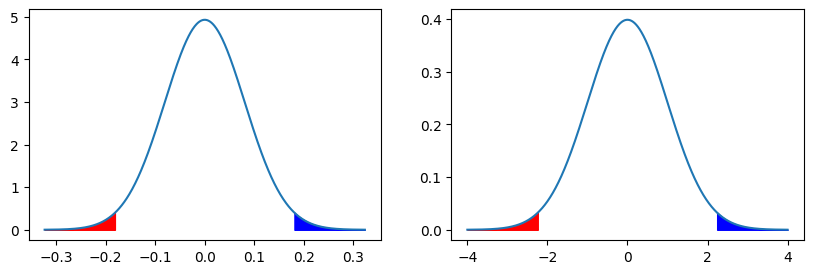

In [ ]:
TwoProportionTest(x1=23,n1=80,x2=30,n2=64,CIs=[0.90,0.95,0.99])

__Example__

87 out of 100 students preparing with Barron's passed the Medical
admission test MCAT, while 91 out of 120 passed it with Princeton Review. Is
there a significant difference at the 1% level? How about a 5% level?

$\textbf{H0}: p_1-p_2 = 0$ (no difference in proportions - __assume true__).  
$\textbf{H1}: p_1-p_2 \ne 0$ (there is difference in proportions).

Two Proportions Test function
Group 1: number of yes x1 = 87, out of n1 = 100
Group 2: number of yes x2 = 91, out of n2 = 120
Confidence Levels [0.9, 0.95, 0.99] 

H0: p1-p2 = 0
H1: p1-p2 not 0  or one sided test

sample proportions ph1 = 87/100 = 0.8700
sample proportions ph2 = 91/120 = 0.7583
Hypothesis Testing Approach:
p pooled = pL = (87+91)/(100+120)=0.8091
success-failure conditions n1*pL,n1*(1-pL),n2*pL, n2*(1-pL) >=10??
  80.9091,19.0909,97.0909,22.9091
Standard Error = SE =sqrt(pL*(1-pL)*(1/n1+1/n2)) =
 = sqrt(0.8091(1-0.8091)(1/100+1/120)) = 0.0532
difference phat1-phat2 = 0.8700-0.7583 = 0.1117
Standardized statistic = z = diffphats/SE = 0.1117/0.0532 = 2.0984
P-values: 2-sided and 1-sided:  0.03586871998573904 0.01793435999286952
Confidence Interval Approach:
success-failure conditions n1*ph1,n1*(1-ph1),n2*ph2, n2*(1-ph2) >=10??
  87.0000,13.0000,91.0000,29.0000
Standard Error = SEci =sqrt(ph1*(1-ph1)/n1+ph1*(1-ph2)/n2)) =
 = sqrt(0.8700(1-0.8700)/100+0.7583(1-0.7583)/120)

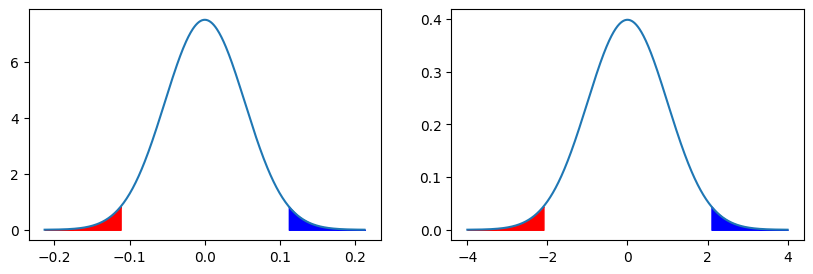

In [ ]:
TwoProportionTest(x1=87,n1=100,x2=91,n2=120,CIs=[0.90,0.95,0.99])

__Example__

In this example, we look again at the substance abusers data set.  We want to investigate if the proportions of people who got treatment are different in homeless vs. housed patients.
Is there a significant difference at the 5% level?  How about a 10% level?

$\textbf{H0}: p_1-p_2 = 0$ (no difference in proportions - __assume true__).  
$\textbf{H1}: p_1-p_2 \ne 0$ (there is difference in proportions).   

In [ ]:
import pandas as pd
url="https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv"
mydata = pd.read_csv(url)

# Note pd.crosstab() is used to cross-tabulate the counts
Om = pd.crosstab(mydata.homeless, mydata.satreat, margins=True);
print(Om)

satreat    no  yes  All
homeless               
homeless  141   68  209
housed    183   61  244
All       324  129  453


Two Proportions Test function
Group 1: number of yes x1 = 68, out of n1 = 209
Group 2: number of yes x2 = 61, out of n2 = 244
Confidence Levels [0.9, 0.95, 0.99] 

H0: p1-p2 = 0
H1: p1-p2 not 0  or one sided test

sample proportions ph1 = 68/209 = 0.3254
sample proportions ph2 = 61/244 = 0.2500
Hypothesis Testing Approach:
p pooled = pL = (68+61)/(209+244)=0.2848
success-failure conditions n1*pL,n1*(1-pL),n2*pL, n2*(1-pL) >=10??
  59.5166,149.4834,69.4834,174.5166
Standard Error = SE =sqrt(pL*(1-pL)*(1/n1+1/n2)) =
 = sqrt(0.2848(1-0.2848)(1/209+1/244)) = 0.0425
difference phat1-phat2 = 0.3254-0.2500 = 0.0754
Standardized statistic = z = diffphats/SE = 0.0754/0.0425 = 1.7717
P-values: 2-sided and 1-sided:  0.07644851371905759 0.038224256859528793
Confidence Interval Approach:
success-failure conditions n1*ph1,n1*(1-ph1),n2*ph2, n2*(1-ph2) >=10??
  68.0000,141.0000,61.0000,183.0000
Standard Error = SEci =sqrt(ph1*(1-ph1)/n1+ph1*(1-ph2)/n2)) =
 = sqrt(0.3254(1-0.3254)/209+0.2500(1-0.2500)

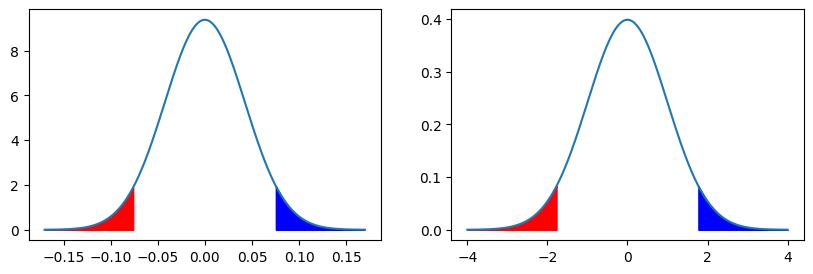

In [ ]:
TwoProportionTest(x1=68,n1=209,x2=61,n2=244,CIs=[0.90,0.95,0.99])